# Class 4: Agentic RAG with LangGraph and LlamaIndex

**Hands-On Exercise Notebook**  
**Postgraduate AI Agents Course - Session 4**

## Exercise Overview

In this hands-on session, you will build an **Agentic RAG system** that:
- Uses **LlamaIndex** for document indexing and retrieval
- Uses **LangGraph** for agent workflow orchestration
- Implements intelligent retrieval decisions (not always retrieves)
- Grades document relevance and rewrites queries if needed
- Maintains conversation state across turns

## Objective Graph
![Workflow Graph](mmd.png)

## Learning Objectives

By completing this exercise, you will:
1. ✅ Build a LlamaIndex knowledge base with multiple documents
2. ✅ Create retrieval tools for LangGraph agents
3. ✅ Implement a complete agentic RAG graph with conditional routing
4. ✅ Compare traditional RAG vs. agentic RAG patterns

---

In [1]:
# Core imports
import os
import warnings
from llama_index.core import SimpleDirectoryReader
from llama_index.readers.file import PyMuPDFReader
warnings.filterwarnings('ignore')

# LlamaIndex imports
from llama_index.core import (
    VectorStoreIndex,
    Document,
    Settings,
)
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.core.node_parser import SentenceSplitter

# LangGraph imports
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# LangChain imports
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

# Pydantic for structured outputs
from pydantic import BaseModel, Field
from typing import Literal

# Semantic Splitter
from llama_index.core.node_parser import SemanticSplitterNodeParser

print("✅ All imports successful!")

2025-12-21 03:51:41.373558: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ All imports successful!


In [2]:
import os
import dotenv
from pathlib import Path

DOT_ENV_PATH = Path.cwd().parent.parent / ".env"

# Load .env file if present
if DOT_ENV_PATH.exists():
    dotenv.load_dotenv(DOT_ENV_PATH)
    print(f"🔄 Loaded environment from: {DOT_ENV_PATH}")
else:
    print(f"⚠️ .env file not found at: {DOT_ENV_PATH}. Continuing...")

# vLLM Configuration
os.environ.setdefault("VLLM_MODEL_NAME", "openai/gpt-oss-20b")

# LangSmith Configuration (Free Tier)
os.environ.setdefault("LANGSMITH_ENDPOINT", "https://eu.api.smith.langchain.com")
os.environ.setdefault("LANGSMITH_TRACING", "true")
os.environ.setdefault("LANGSMITH_PROJECT", "email-triage-agent")

# Required environment variables
REQUIRED_ENV_VARS = {
    "VLLM_BASE_URL",
    "VLLM_API_KEY",
    "LANGSMITH_API_KEY",
}

print("\n🔍 Validating required environment variables...\n")

missing = []
for var in REQUIRED_ENV_VARS:
    value = os.getenv(var)
    if value is None or value.strip() == "":
        print(f"❌ Missing: {var}")
        missing.append(var)
    else:
        print(f"✅ {var} = {value[:4]}**** (loaded)")

if missing:
    print("\n❗ ERROR: Missing required environment variables:")
    for var in missing:
        print(f"   - {var}")
    print("\n💡 Fix: Add them to your .env file or your environment before running this script.")

print("\n🎉 All required environment variables are set correctly!")


# Configure embedding model (free, local)
embed_model = HuggingFaceEmbedding(
    model_name="intfloat/multilingual-e5-large"
)
Settings.embed_model = embed_model

# Configure LLM
# Connect to your vLLM server (OpenAI-compatible)
llm = ChatOpenAI(
    base_url=os.getenv("VLLM_BASE_URL"),
    api_key=os.getenv("VLLM_API_KEY"),
    model=os.getenv("VLLM_MODEL_NAME"),
    temperature=0.0,
)

print("✅ Connected to vLLM server")

print("✅ Configuration complete!")
print(f"Embedding model: {embed_model.model_name}")
print(f"LLM: {llm.model_name}")

2025-12-21 03:51:45,849 - INFO - Load pretrained SentenceTransformer: intfloat/multilingual-e5-large


🔄 Loaded environment from: /home/sagemaker-user/agentic-ai-course-main/agentic-ai-course-main/.env

🔍 Validating required environment variables...

✅ VLLM_API_KEY = <VLL**** (loaded)
✅ VLLM_BASE_URL = http**** (loaded)
✅ LANGSMITH_API_KEY = <LAN**** (loaded)

🎉 All required environment variables are set correctly!
✅ Connected to vLLM server
✅ Configuration complete!
Embedding model: intfloat/multilingual-e5-large
LLM: openai/gpt-oss-20b


---

## Step 1: Create Knowledge Base Documents

We'll create a comprehensive set of AI governance documents:
1. **AI Safety Policy** - Core principles and requirements
2. **Model Deployment Checklist** - Pre-deployment requirements
3. **Incident Response Protocol** - How to handle AI failures
4. **Bias Audit Guidelines** - Testing for fairness
5. **Data Privacy Standards** - Data handling requirements
6. **Human Oversight Framework** - When humans must review decisions

This simulates a realistic organizational knowledge base.

In [3]:
# Define your PDF directory or specific file paths
pdf_directory = "SRIJ_docs/"  # Pasta com os documentos

# Carregar os PDFs através do diretório, com PyMuPDFReader para evitar texto corrompido
reader = SimpleDirectoryReader(
    input_dir=pdf_directory,
    required_exts=[".pdf"],
    file_extractor={".pdf": PyMuPDFReader()}  # <-- Esta linha força o uso do PyMuPDF (resolve o problema de caracteres estranhos)
)
documents = reader.load_data()

# Processamento para adicionar metadat
metadata_mapping = {
    "Consolidacao_Decreto_Lei_n_66_2015_Diário da República_n_83_2015_0.pdf": {
        "source": "Regime Jurídico dos Jogos e Apostas Online ",
        "version": "7.0",
        "doc_type": "Lei Geral",
        "classification": "Público"
    }
}

# Aplicar custom metadata para cada 1 dos documentos carregados
for doc in documents:
    filename = doc.metadata.get("file_name")  # SimpleDirectoryReader adiciona isto automaticamente
    if filename in metadata_mapping:
        doc.metadata.update(metadata_mapping[filename])
    else:
        print(f"Warning: No metadata mapping for {filename}. Using defaults.")
        doc.metadata.update({"source": filename.replace(".pdf", ""), "version": "1.0", "doc_type": "unknown"})

print(f"✅ Loaded {len(documents)} documents from PDFs:")
for i, doc in enumerate(documents, 1):
    print(f"{i}. {doc.metadata['source']} (v{doc.metadata.get('version', 'N/A')})")
    print(f"   Type: {doc.metadata['doc_type']}")
    print(f"   Length: {len(doc.text):,} characters\n")

print(f"Total knowledge base size: {sum(len(d.text) for d in documents):,} characters")

✅ Loaded 59 documents from PDFs:
1. Regime Jurídico dos Jogos e Apostas Online  (v7.0)
   Type: Lei Geral
   Length: 1,889 characters

2. Regime Jurídico dos Jogos e Apostas Online  (v7.0)
   Type: Lei Geral
   Length: 2,155 characters

3. Regime Jurídico dos Jogos e Apostas Online  (v7.0)
   Type: Lei Geral
   Length: 2,114 characters

4. Regime Jurídico dos Jogos e Apostas Online  (v7.0)
   Type: Lei Geral
   Length: 755 characters

5. Regime Jurídico dos Jogos e Apostas Online  (v7.0)
   Type: Lei Geral
   Length: 5,023 characters

6. Regime Jurídico dos Jogos e Apostas Online  (v7.0)
   Type: Lei Geral
   Length: 5,256 characters

7. Regime Jurídico dos Jogos e Apostas Online  (v7.0)
   Type: Lei Geral
   Length: 3,081 characters

8. Regime Jurídico dos Jogos e Apostas Online  (v7.0)
   Type: Lei Geral
   Length: 2,006 characters

9. Regime Jurídico dos Jogos e Apostas Online  (v7.0)
   Type: Lei Geral
   Length: 3,967 characters

10. Regime Jurídico dos Jogos e Apostas Online  (v7

---

## Step 2: Build LlamaIndex Knowledge Base

Now we'll index these documents for semantic search using LlamaIndex.

In [4]:
# Build vector index from documents
print("Building vector index with Semantic Splitter...")
print("This may take a few minutes as it analyzes semantic breaks.\n")

# Utiliza-se o Semantic Splitter
semantic_splitter = SemanticSplitterNodeParser(
    buffer_size=1,                          # Pequeno para capturar mudanças rápidas
    breakpoint_percentile_threshold=95,     # Deteta mudanças de tópico fortes (95% = agressivo)
    embed_model=embed_model                 # Para utilizar multilingual-e5-large
)

# Obtém os nodes semanticamente divididos
nodes = semantic_splitter.get_nodes_from_documents(documents)

# Cria o índice a partir dos nodes semânticos
index = VectorStoreIndex(
    nodes,
    show_progress=True
)

print("\n✅ Vector index created successfully!")
print(f"Indexed {len(index.docstore.docs)} nodes")


index.storage_context.persist("./SRIJ_docs_index")

Building vector index with Semantic Splitter...
This may take a few minutes as it analyzes semantic breaks.



Generating embeddings:   0%|          | 0/114 [00:00<?, ?it/s]


✅ Vector index created successfully!
Indexed 114 nodes


---

## Step 3: Create Retrieval Tool for LangGraph

We'll wrap the LlamaIndex retriever as a tool that the LangGraph agent can call.

In [5]:
print(documents[0].text[:1000])  # Mostra os primeiros 1000 caracteres do documento para ver se a leitura foi bem efetuada

Decreto-Lei n.º 66/2015, de 29 de abril
Com as alterações introduzidas por: 
Lei n.º 13/2017; Lei n.º 101/2017; Lei n.º 114/2017; Lei n.º 49/2018; Decreto-Lei n.º 84/2019; Lei n.º
2/2020.
Índice
Diploma
Artigo 1.º
Objeto
Artigo 2.º
Aprovação do Regime Jurídico dos Jogos e Apostas Online
Artigo 3.º
Alteração ao Código da Publicidade
Artigo 4.º
Alteração à Tabela Geral do Imposto do Selo
Artigo 5.º
Alteração ao Decreto-Lei n.º 129/2012, de 22 de junho
Artigo 6.º
Reavaliação
Artigo 7.º
Disposições transitórias
Artigo 8.º
Norma revogatória
Artigo 9.º
Republicação
Artigo 10.º
Entrada em vigor
Anexo I
(a que se refere o artigo 2.º)
Capítulo I
Disposições gerais
Artigo 1.º
Objeto
Artigo 2.º
Âmbito objetivo
Artigo 3.º
Âmbito territorial
Artigo 4.º
Definições
Artigo 5.º
Categorias e tipos de jogos e apostas online autorizados
Capítulo II
Proibições e política de jogo responsável
Artigo 6.º
Proibições
Artigo 7.º
Política de jogo responsável
Capítulo III
Exploração e prática dos jogos e apostas o

In [6]:
# Create retriever
retriever = index.as_retriever(similarity_top_k=10)

# Create tool function
@tool
def retrieve_gambling_law_docs(query: str) -> str:
    """
    Search AI governance knowledge base for relevant policies and procedures.
    
    Use this tool when questions are about:
    - AI safety principles and requirements
    - Model deployment procedures
    - Incident response protocols  
    - Bias auditing guidelines
    - Data privacy standards
    - Human oversight requirements
    """
    # Retrieve relevant nodes
    nodes = retriever.retrieve(query)
    
    # Format results
    context_parts = []
    for i, node in enumerate(nodes, 1):
        source = node.metadata.get('source', 'unknown')
        context_parts.append(
            f"[Document {i}: {source}]\n{node.text}\n"
        )
    
    return "\n---\n".join(context_parts)

# Store tool in list
tools = [retrieve_gambling_law_docs]

print("✅ Retrieval tool created!")
print(f"Tool name: {tools[0].name}")
print(f"Tool description: {tools[0].description}")

✅ Retrieval tool created!
Tool name: retrieve_gambling_law_docs
Tool description: Search AI governance knowledge base for relevant policies and procedures.

Use this tool when questions are about:
- AI safety principles and requirements
- Model deployment procedures
- Incident response protocols  
- Bias auditing guidelines
- Data privacy standards
- Human oversight requirements


---

## Step 4: Build Agentic RAG Graph with LangGraph

Now we'll implement the complete agentic RAG workflow:
1. Query generation (decide to retrieve or respond)
2. Retrieval (if needed)
3. Document grading
4. Answer generation or query rewriting

### 4.1 Define State

In [7]:
# Use MessagesState from LangGraph
# This automatically manages conversation history

from langgraph.graph import MessagesState

class CustomMessagesState(MessagesState):
    retrieval_score: str

print("✅ Using CustomMessagesState for graph state management")

✅ Using CustomMessagesState for graph state management


### 4.2 Node: Query Generation or Direct Response

In [8]:
def generate_query_or_respond(state: CustomMessagesState):
    """
    LLM decides: use retrieval tool or respond directly.
    """
    print("\n🤖 Node: generate_query_or_respond")
    
    messages = state["messages"]
    
    # Bind tools to LLM so it can decide to use them
    response = llm.bind_tools(tools).invoke(messages)
    
    # Check if LLM called tools
    if response.tool_calls:
        print(f"   → LLM decided to retrieve: {response.tool_calls[0]['name']}")
    else:
        print("   → LLM responded directly (no retrieval needed)")
    
    return {"messages": [response]}

print("✅ Node 1 defined: generate_query_or_respond")

✅ Node 1 defined: generate_query_or_respond


### 4.3 Node: Retrieval (ToolNode)

In [9]:
# ToolNode automatically executes tools from AIMessage.tool_calls
retrieve_node = ToolNode(tools)

print("✅ Node 2 defined: retrieve (ToolNode)")

✅ Node 2 defined: retrieve (ToolNode)


### 4.4 Node: Document Grading

In [10]:
# Define structured output schema
class GradeDocuments(BaseModel):
    """Binary relevance score for retrieved documents."""
    binary_score: Literal["yes", "no"] = Field(
        description="Documents are relevant to the question: 'yes' or 'no'"
    )

GRADE_PROMPT = """Tu és um avaliador que verifica a relevância de documentos legais portugueses para resposta à pergunta colocada.

Contexto recuperado:
{context}

Pergunta: {question}

Classifica como 'yes' se houver QUALQUER menção, mesmo indireta, a conceitos relacionados com a pergunta, como por exemplo jogos e apostas online.
Só classifica 'no' se for completamente irrelevante.
Responde apenas 'yes' ou 'no'."""

# LLM with structured output
grader_llm = llm.with_structured_output(GradeDocuments)

def grade_documents(state: CustomMessagesState) -> dict:
    """
    Evaluate if retrieved docs are relevant.
    Routes to answer generation or query rewriting.
    """
    print("\n📊 Node: grade_documents")
    
    messages = state["messages"]
    question = messages[0].content  # Original user question
    
    # Get retrieved context from tool message
    tool_messages = [m for m in messages if isinstance(m, ToolMessage)]
    if not tool_messages:
        print("   ⚠️  No tool messages found, defaulting to generate")
        return {"retrieval_score": "yes"}
    
    context = tool_messages[-1].content  # Most recent retrieval
    
    # Grade relevance
    prompt = GRADE_PROMPT.format(question=question, context=context) 
    score = grader_llm.invoke([{"role": "user", "content": prompt}])

    return {"retrieval_score": score.binary_score}

def relevant_check(state: CustomMessagesState):
    print(state) # retirar depois na resposta
    score = state["retrieval_score"]
    if score == "yes":
        print("   ✅ Documents are RELEVANT → generate_answer")
        return "generate_answer"
    else:
        print("   ❌ Documents NOT relevant → rewrite_query")
        return "rewrite_query"

print("✅ Node 3 defined: grade_documents")

✅ Node 3 defined: grade_documents


### 4.5 Node: Query Rewriting

In [11]:
REWRITE_PROMPT = """Tu és um reformulador de perguntas para melhorar resultados de busca.

Pergunta original:
{question}

A busca anterior não encontrou resultados relevantes.
Reformula a pergunta de forma mais específica e clara, focando em termos chave da legislação.
Nova pergunta:"""

def rewrite_query(state: CustomMessagesState):
    """
    Reformulate query to improve retrieval quality.
    """
    print("\n✏️  Node: rewrite_query")
    
    messages = state["messages"]
    original_question = messages[0].content
    
    prompt = REWRITE_PROMPT.format(question=original_question)
    response = llm.invoke([{"role": "user", "content": prompt}])
    
    print(f"   Original: {original_question}")
    print(f"   Rewritten: {response.content}")
    
    # Replace original question with rewritten version
    return {"messages": [HumanMessage(content=response.content)]}

print("✅ Node 4 defined: rewrite_query")

✅ Node 4 defined: rewrite_query


### 4.6 Node: Answer Generation

In [12]:
GENERATE_PROMPT = """Tu és um assistente especializado em legislação portuguesa de jogos e apostas online.

Usa o contexto recuperado para responder à pergunta de forma precisa, clara e em português.
Se o contexto não tiver a resposta, diz que não encontraste informação no documento sobre isso.
Cita artigos ou secções quando possível.

Pergunta: {question}

Contexto:
{context}

Resposta:"""

def generate_answer(state: CustomMessagesState):
    """
    Generate final answer using retrieved context.
    """
    print("\n💡 Node: generate_answer")
    
    messages = state["messages"]
    question = messages[0].content
    
    # Get retrieved context
    tool_messages = [m for m in messages if isinstance(m, ToolMessage)]
    context = tool_messages[-1].content if tool_messages else "No context retrieved."
    
    # Generate answer
    prompt = GENERATE_PROMPT.format(
        question=question,
        context=context[:3000]  # Truncate to fit token limits
    )
    response = llm.invoke([{"role": "user", "content": prompt}])
    
    print(f"   Generated answer: {response.content[:100]}...")
    
    return {"messages": [response]}

print("✅ Node 5 defined: generate_answer")

✅ Node 5 defined: generate_answer


### 4.7 Assemble the Graph

In [13]:
# Build the graph
workflow = StateGraph(CustomMessagesState)

# Add all nodes
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", retrieve_node)
workflow.add_node("grade_documents", grade_documents)  # Wrapper for routing
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_answer", generate_answer)

# Add edges
workflow.add_edge(START, "generate_query_or_respond")

# Conditional: Did LLM call tool?
workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,  # Built-in: checks for tool_calls
    {
        "tools": "retrieve",  # If tool_calls present
        END: END              # If no tool_calls
    }
)

# After retrieval, grade documents
workflow.add_edge("retrieve", "grade_documents")

workflow.add_conditional_edges(
    "grade_documents",
    relevant_check,
    {
        "generate_answer": "generate_answer",
        "rewrite_query": "rewrite_query"  
    }
)

# Conditional: Are docs relevant?
# Note: grade_documents function returns the routing decision
def route_after_grading(state: CustomMessagesState):
    return grade_documents(state)

workflow.add_conditional_edges(
    "grade_documents",
    route_after_grading
)

# After answer generation, end
workflow.add_edge("generate_answer", END)

# After query rewriting, loop back to start
workflow.add_edge("rewrite_query", "generate_query_or_respond")

# Compile graph
graph = workflow.compile()

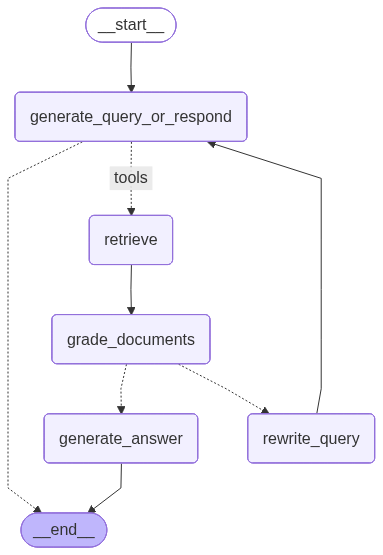

In [14]:
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

---

## Step 5: Test the Agentic RAG System

### 5.1 Test: Policy Question (Should Retrieve)

In [15]:
# Test query that requires retrieval
test_query_1 = "Um jogador pode autoexcluir-se dos jogos e apostas online em Portugal? Qual o período mínimo de autoexclusão?"

print(f"Query: {test_query_1}")
print("="*70)

inputs = {"messages": [HumanMessage(content=test_query_1)]}

# Get final result
final_state = graph.invoke(inputs)
final_answer = final_state["messages"][-1].content

print("\n" + "="*70)
print("FINAL ANSWER:")
print("="*70)

2025-12-21 04:06:00,188 - WARNING - Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


Query: Um jogador pode autoexcluir-se dos jogos e apostas online em Portugal? Qual o período mínimo de autoexclusão?

🤖 Node: generate_query_or_respond


2025-12-21 04:06:01,449 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   → LLM decided to retrieve: retrieve_gambling_law_docs

📊 Node: grade_documents


2025-12-21 04:06:02,213 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 04:06:05,624 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


...

2025-12-21 04:06:06,177 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 04:06:08,283 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"
2025-12-21 04:06:08,289 - WARNING - Task grade_documents with path ('__pregel_pull', 'grade_documents') wrote to unknown channel branch:to:{'retrieval_score': 'yes'}, ignoring it.



💡 Node: generate_answer


2025-12-21 04:06:08,820 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 04:06:17,374 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   Generated answer: Sim.  
De acordo com a legislação portuguesa de jogos e apostas online, o jogador tem o direito de s...

FINAL ANSWER:


2025-12-21 04:06:17,906 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [19]:
# Test query that requires retrieval
test_query_1 = "Qual é a redação alinea g) do artigo 56º do Decreto-Lei n.º 66/2015, de 29 de abril que aprova o regime juridico dos jogos e apostas online?"

print(f"Query: {test_query_1}")
print("="*70)

inputs = {"messages": [HumanMessage(content=test_query_1)]}

# Get final result
final_state = graph.invoke(inputs)
final_answer = final_state["messages"][-1].content

print("\n" + "="*70)
print("FINAL ANSWER:")
print(final_answer)
print("="*70)

Query: Qual é a redação alinea g) do artigo 56º do Decreto-Lei n.º 66/2015, de 29 de abril que aprova o regime juridico dos jogos e apostas online?

🤖 Node: generate_query_or_respond


2025-12-21 04:09:03,076 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 04:09:04,521 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   → LLM decided to retrieve: retrieve_gambling_law_docs

📊 Node: grade_documents


2025-12-21 04:09:05,316 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 04:09:07,187 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


{'messages': [HumanMessage(content='Qual é a redação alinea g) do artigo 56º do Decreto-Lei n.º 66/2015, de 29 de abril que aprova o regime juridico dos jogos e apostas online?', additional_kwargs={}, response_metadata={}, id='54a8717e-fe1f-40cb-9792-ae7c55f91a6f'), AIMessage(content='{"query":"Decreto-Lei 66/2015 artigo 56 alinea g"}', additional_kwargs={'tool_calls': [{'id': 'chatcmpl-tool-da7f489ab99e42b9b43ae5aabd43ac29', 'function': {'arguments': '{"query":"Decreto-Lei 66/2015 artigo 56 alinea g"}', 'name': 'retrieve_gambling_law_docs'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 181, 'prompt_tokens': 217, 'total_tokens': 398, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': None, 'id': 'chatcmpl-da6945dc51c743ec878549dccf1d0a3d', 'service_tier': None, 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--dd6ddfab-8262-4176-a106-86f65cd135a7-0', too

2025-12-21 04:09:07,727 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 04:09:09,454 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"
2025-12-21 04:09:09,461 - WARNING - Task grade_documents with path ('__pregel_pull', 'grade_documents') wrote to unknown channel branch:to:{'retrieval_score': 'no'}, ignoring it.



💡 Node: generate_answer


2025-12-21 04:09:09,993 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 04:09:13,510 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   Generated answer: Não encontrei informação no documento sobre a redação da alínea g) do artigo 56º do Decreto‑Lei n.º ...

FINAL ANSWER:
Não encontrei informação no documento sobre a redação da alínea g) do artigo 56º do Decreto‑Lei n.º 66/2015, de 29 de abril.


2025-12-21 04:09:14,042 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [23]:
# Test query that requires retrieval
test_query_1 = "Em jogos e apostas online quais são as consequências para uma entidade exploradora que não pague o valor do prémio anunciado?"

print(f"Query: {test_query_1}")
print("="*70)

inputs = {"messages": [HumanMessage(content=test_query_1)]}

# Get final result
final_state = graph.invoke(inputs)
final_answer = final_state["messages"][-1].content

print("\n" + "="*70)
print("FINAL ANSWER:")
print(final_answer)
print("="*70)

Query: Em jogos e apostas online quais são as consequências para uma entidade exploradora que não pague o valor do prémio anunciado?

🤖 Node: generate_query_or_respond


2025-12-21 04:17:54,277 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 04:17:54,941 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   → LLM decided to retrieve: retrieve_gambling_law_docs

📊 Node: grade_documents


2025-12-21 04:17:56,086 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 04:18:01,126 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


{'messages': [HumanMessage(content='Em jogos e apostas online quais são as consequências para uma entidade exploradora que não pague o valor do prémio anunciado?', additional_kwargs={}, response_metadata={}, id='122df78e-0f8d-47b3-ba30-19f0d67d9f06'), AIMessage(content='{"query":"consequências para entidade exploradora que não pague valor do prémio anunciado jogos apostas online"}', additional_kwargs={'tool_calls': [{'id': 'chatcmpl-tool-5a9cbbc98f4c49bd99b06d889a409f5a', 'function': {'arguments': '{"query":"consequências para entidade exploradora que não pague valor do prémio anunciado jogos apostas online"}', 'name': 'retrieve_gambling_law_docs'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 109, 'prompt_tokens': 198, 'total_tokens': 307, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': None, 'id': 'chatcmpl-1b9383cdab414580bfac4ba78742fcf7', 'service_tier': 

...

2025-12-21 04:18:07,429 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 04:18:10,303 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   Original: Em jogos e apostas online quais são as consequências para uma entidade exploradora que não pague o valor do prémio anunciado?
   Rewritten: **Nova pergunta:**

> De acordo com a legislação portuguesa e a regulamentação da Autoridade Nacional do Jogo (ANJ), quais são as sanções, penalidades e consequências legais aplicáveis a um operador de jogos e apostas online que não efetua o pagamento de prémios anunciados?

🤖 Node: generate_query_or_respond


2025-12-21 04:18:10,838 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 04:18:40,446 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   → LLM responded directly (no retrieval needed)

FINAL ANSWER:
**Sanções, penalidades e consequências legais para um operador de jogos e apostas online que não paga prémios anunciados**  
*(legislação portuguesa – Regime Jurídico dos Jogos e Apostas Online (RJO) e regulamentos da Autoridade Nacional do Jogo – ANJ)*  

| Tipo de sanção | Base legal | Condição / Escopo | Valor / Prazo | Observações |
|----------------|------------|-------------------|---------------|-------------|
| **1. Sanções administrativas (coimas)** | Art. 60‑69 do RJO (Regulamento de Sanções Administrativas) | Falha em pagar prémios, não manter saldo mínimo na conta bancária de pagamento, não cumprir ordem de pagamento da ANJ, etc. | 10 % do volume de negócios anual da entidade, **máximo de € 500 000** (ou 10 % do volume de negócios, se superior).  <br>Para cada contravenção grave (Art. 57) a coima pode ser aplicada separadamente. | A coima pode ser aumentada se houver reincidência ou se a infração for considera

2025-12-21 04:18:40,978 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


### 5.2 Test: Simple Question (Direct Response)

In [17]:
# Test query that doesn't need retrieval
test_query_2 = "Hello, how are you?"

print(f"Query: {test_query_2}")
print("="*70)

inputs = {"messages": [HumanMessage(content=test_query_2)]}


final_state = graph.invoke(inputs)
final_answer = final_state["messages"][-1].content

print("\n" + "="*70)
print("FINAL ANSWER:")
print(final_answer)
print("="*70)
print("\n💡 Notice: Agent responded directly without retrieval!")

Query: Hello, how are you?

🤖 Node: generate_query_or_respond


2025-12-21 00:23:14,812 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
2025-12-21 00:23:14,910 - INFO - HTTP Request: POST http://54.217.173.51:8000/v1/chat/completions "HTTP/1.1 200 OK"


   → LLM responded directly (no retrieval needed)

FINAL ANSWER:
Hello! I'm just a bunch of code, but I'm here and ready to help. How can I assist you today?

💡 Notice: Agent responded directly without retrieval!


2025-12-21 00:23:15,443 - WARNING - Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


### 5.3 Test: Complex Multi-Part Question

In [20]:
# Test complex query
test_query_3 = "What testing must be completed before deploying a HIGH RISK AI system, and how often must bias audits be conducted?"

print(f"Query: {test_query_3}")
print("="*70)

inputs = {"messages": [HumanMessage(content=test_query_3)]}


final_state = graph.invoke(inputs)
final_answer = final_state["messages"][-1].content

print("\n" + "="*70)
print("FINAL ANSWER:")
print(final_answer)
print("="*70)

Query: What testing must be completed before deploying a HIGH RISK AI system, and how often must bias audits be conducted?

🤖 Node: generate_query_or_respond


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


   → LLM decided to retrieve: retrieve_governance_docs

📊 Node: grade_documents


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='What testing must be completed before deploying a HIGH RISK AI system, and how often must bias audits be conducted?', additional_kwargs={}, response_metadata={}, id='d456e2d8-0cb7-4bca-998e-136fe2745404'), AIMessage(content='{"query":"HIGH RISK AI system testing before deployment bias audits frequency"}', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 83, 'prompt_tokens': 195, 'total_tokens': 278, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': None, 'id': 'chatcmpl-f299961272714ad4add4ef36aa0edeeb', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b39d9-aafe-77c3-aee9-a6e80aac7ec7-0', tool_calls=[{'name': 'retrieve_governance_docs', 'args': {'query': 'HIGH RISK AI system testing before deployment bias audits frequency'}, 'id': 'chatcmpl-tool-5874445a233045c9a7677bb39a1725b0', 'type': '

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Task grade_documents with path ('__pregel_pull', 'grade_documents') wrote to unknown channel branch:to:{'retrieval_score': 'yes'}, ignoring it.



💡 Node: generate_answer


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


   Generated answer: **Pre‑deployment testing required for a HIGH‑RISK AI system**

According to the *AI Model Deployment...

FINAL ANSWER:
**Pre‑deployment testing required for a HIGH‑RISK AI system**

According to the *AI Model Deployment Checklist* (Version 1.5, Oct 2024), before any AI model—especially a HIGH‑RISK system—can be deployed, the following tests must all pass:

| Test | Key requirements |
|------|------------------|
| **Unit Testing** | All model components have passing unit tests; ≥ 80 % code coverage; edge cases documented and tested. |
| **Integration Testing** | Correct integration with upstream/downstream systems; API contracts validated; error handling for all failure modes tested. |
| **Adversarial Testing** | Model evaluated against adversarial inputs; robustness to input perturbations verified; prompt‑injection attacks tested (for LLMs). |
| **Performance Benchmarking** | Latency under expected load measured; throughput capacity determined; resource utilization

In [21]:
# Test complex query
test_query_4 = "What is the safest way to train a model?"

print(f"Query: {test_query_4}")
print("="*70)

inputs = {"messages": [HumanMessage(content=test_query_4)]}

final_state = graph.invoke(inputs)
final_answer = final_state["messages"][-1].content

print("\n" + "="*70)
print("FINAL ANSWER:")
print(final_answer)
print("="*70)

Query: What is the safest way to train a model?

🤖 Node: generate_query_or_respond


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


   → LLM decided to retrieve: retrieve_governance_docs

📊 Node: grade_documents


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='What is the safest way to train a model?', additional_kwargs={}, response_metadata={}, id='2bd97c8b-2d74-4704-8206-629d533bbec0'), AIMessage(content='{"query":"safest way to train a model AI governance safety principles training procedures"}', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 64, 'prompt_tokens': 182, 'total_tokens': 246, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': None, 'id': 'chatcmpl-e56732da10c04b239b925569fe37567f', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b39d9-fa80-7310-8fe2-eaf417cc9bab-0', tool_calls=[{'name': 'retrieve_governance_docs', 'args': {'query': 'safest way to train a model AI governance safety principles training procedures'}, 'id': 'chatcmpl-tool-4638077733fe4762b3025f5297756d7c', 'type': 'tool_call'}], usage_metadata={'input_tokens': 182, 

...

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


   Original: What is the safest way to train a model?
   Rewritten: **Revised Question**

*What are the best practices for safely training a machine‑learning model—covering data privacy, bias mitigation, and protection against adversarial attacks?*

🤖 Node: generate_query_or_respond


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


   → LLM responded directly (no retrieval needed)

FINAL ANSWER:
Below is a concise, practical “playbook” you can follow (or adapt) when you’re training a new ML model.  
It pulls together the key requirements from our AI‑Safety Policy, the risk‑assessment framework, and the deployment checklist, and it is organized into three core safety pillars:

| Pillar | Key Objectives | Practical Steps | Governance Touch‑points |
|--------|----------------|-----------------|------------------------|
| **Data Privacy** | • Protect personal data • Comply with GDPR/CCPA/other laws | • Data minimization (only keep what you need) <br>• Anonymise / pseudonymise before training <br>• Use secure storage (encryption at rest & in transit) <br>• Implement a data‑access audit trail <br>• Provide a “right‑to‑be‑forgotten” mechanism for training data | • AI Safety Lead signs off on data‑privacy impact assessment <br>• Privacy officer reviews consent & deletion logs |
| **Bias Mitigation** | • Ensure fairness a

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


---

## Exercise Complete! 🎉

### What You Built

You successfully created an **Agentic RAG system** that:

✅ **Indexes comprehensive governance documents** (6 policy documents with 15,000+ characters)

✅ **Makes intelligent retrieval decisions** (doesn't always retrieve)

✅ **Grades document relevance** (can detect when retrieval didn't help)

✅ **Rewrites queries** when needed (iterative improvement)

### Key Insights

**Agentic RAG vs Traditional RAG:**
- **Traditional**: Always retrieves, even for simple questions
- **Agentic**: LLM decides when retrieval is needed
- **Benefit**: More efficient, better user experience

**LangGraph Advantages:**
- **Conditional routing**: Different paths based on decisions
- **Iterative refinement**: Can loop back and retry
- **State management**: Conversation history maintained automatically
- **Observability**: Each node execution is traceable

**LlamaIndex + LangGraph:**
- LlamaIndex handles retrieval pipeline (indexing, embedding, querying)
- LangGraph handles agent orchestration (decision-making, routing)
- Together: Best of both frameworks!

---

## Extension Challenges

Try these to deepen your understanding:

### Challenge 1: Add More Tools
Create a second retrieval tool for a different knowledge base (e.g., technical documentation) and let the agent choose which to use.

### Challenge 2: Implement Confidence Scoring
Add a node that evaluates the confidence of the generated answer and routes low-confidence answers to human review.

### Challenge 3: Hybrid Search
Combine vector search (LlamaIndex) with keyword search (BM25) for better retrieval.

### Challenge 4: Add Web Search Fallback
If internal documents don't have the answer, add a node that searches the web.

### Challenge 5: Build a UI
Create a Streamlit or Gradio interface that visualizes the graph execution in real-time.

---

## Resources for Further Learning

- [LlamaIndex Documentation](https://docs.llamaindex.ai/)
---

**Great work! You're now ready to build production-grade agentic RAG systems.** 🚀
